In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy.stats
from scipy.stats import norm, lognorm, expon
from pathlib import Path
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
csv_path = PROJECT_ROOT / "data" / "processed" / "dataset_full.csv"
df = pd.read_csv(csv_path)
df = df[df['district'] != 'unknown']

In [2]:
df.head()
print(df.columns)
print(f"Нет значений в годах: {sum(df['year'].isna())}")
print(f"Нет значений в расстоянии до метро: {sum(df['distance_to_metro'].isna())}")
print(f"Распределение по районам {df['district'].value_counts()}")
print(f"Объектов, признаков{len(df), len(df.columns)}")

Index(['rooms', 'district', 'year', 'material', 'price', 'total_area',
       'living_area', 'kitchen_area', 'current_floor', 'max_floor', 'is_ready',
       'metro', 'mini_disctrict', 'price_mln', 'price_log', 'is_last_floor',
       'is_first_floor', 'living_ratio', 'kitchen_ratio', 'floor_ratio',
       'area_floor_interaction', 'district_ready', 'material_age',
       'area_ratio_to_district', 'floor_category', 'distance_to_center',
       'distance_to_metro'],
      dtype='str')
Нет значений в годах: 1076
Нет значений в расстоянии до метро: 2356
Распределение по районам district
Нижегородский район    1128
Советский район         806
Канавинский район       647
Автозаводский район     545
Сормовский район        335
Ленинский район         314
Приокский район         305
Московский район        219
Name: count, dtype: int64
Объектов, признаков(4299, 27)


PRICE info

Статистический анализ распределения цен на квартиры


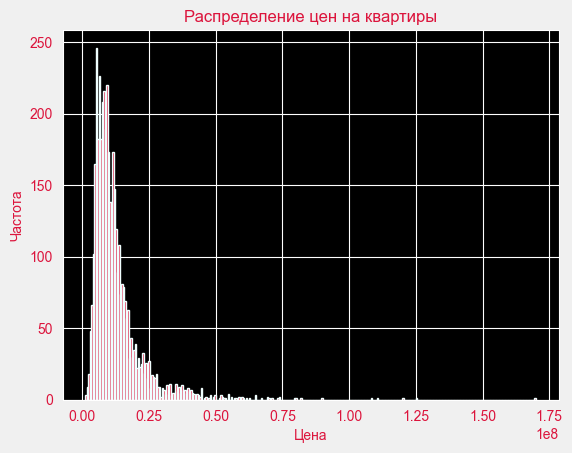

Среднее арифметическое: 12463015.76785299
Стандартное отклонение: 9889065.608760083
Медианное значение: 9790000.0
16-й перцентиль: 5726093.6800000025 25-й перцентиль : 6795000.0 75-й перцентиль : 14509999.5
Скошенность распределения: 4.108835098080127
Выбросность распределения: 33.36796227871915


In [3]:
print("Статистический анализ распределения цен на квартиры")

plt.figure(facecolor='#f0f0f0', )
mpl.rcParams['text.color'] = 'crimson'
plt.hist(df['price'], bins=300, color='crimson', edgecolor='azure')
plt.title('Распределение цен на квартиры')
plt.xlabel('Цена', color = 'crimson')
plt.ylabel('Частота', color = 'crimson')
plt.tick_params(axis='x', colors='crimson')    # Только для оси X
plt.tick_params(axis='y', colors='crimson')
plt.show()
print(f"Среднее арифметическое: {df['price'].mean()}")
print(f"Стандартное отклонение: {df['price'].std()}")
print(f"Медианное значение: {df['price'].median()}")
print(f"16-й перцентиль: {df['price'].quantile(0.16)} 25-й перцентиль : {df['price'].quantile(0.25)} 75-й перцентиль : {df['price'].quantile(0.75)}")
print(f"Скошенность распределения: {df['price'].skew()}")
print(f"Выбросность распределения: {df['price'].kurt()}")

Статистический анализ распределения плоащади на квартиры


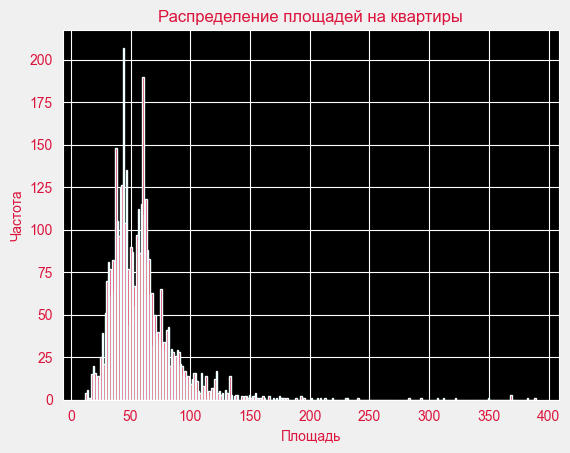

Среднее арифметическое: 58.92488914819137
Стандартное отклонение: 29.197602415351433
Медианное значение: 54.7
16-й перцентиль: 37.2 25-й перцентиль : 41.47 75-й перцентиль : 67.54
Скошенность распределения: 3.513831584970465
Выбросность распределения: 26.221118025213666
54.598150033144236


In [4]:
print("Статистический анализ распределения плоащади на квартиры")
total_area_log = np.log1p(df['total_area'])
plt.figure(facecolor='#f0f0f0', )
mpl.rcParams['text.color'] = 'crimson'
plt.hist(df['total_area'], bins=300, color='crimson', edgecolor='azure')
plt.title('Распределение площадей на квартиры')
plt.xlabel('Площадь', color = 'crimson')
plt.ylabel('Частота', color = 'crimson')
plt.tick_params(axis='x', colors='crimson')    # Только для оси X
plt.tick_params(axis='y', colors='crimson')
plt.show()
print(f"Среднее арифметическое: {df['total_area'].mean()}")
print(f"Стандартное отклонение: {df['total_area'].std()}")
print(f"Медианное значение: {df['total_area'].median()}")
print(f"16-й перцентиль: {df['total_area'].quantile(0.16)} 25-й перцентиль : {df['total_area'].quantile(0.25)} 75-й перцентиль : {df['total_area'].quantile(0.75)}")
print(f"Скошенность распределения: {df['total_area'].skew()}")
print(f"Выбросность распределения: {df['total_area'].kurt()}")
print(np.exp(4))

ГРАФИК РАСПРЕДЕЛЕНИЯ ДИСТАНЦИИ ДО МЕТРО

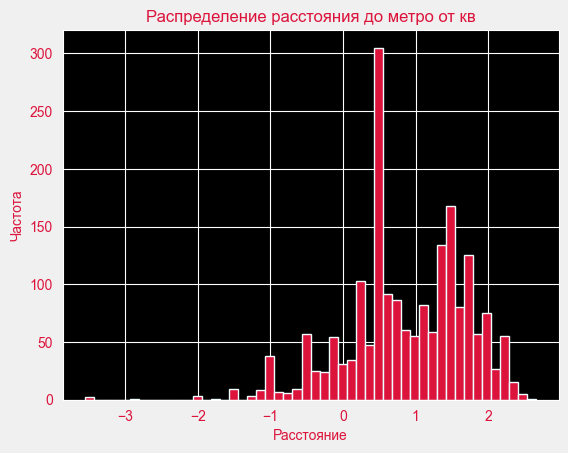

In [5]:
plt.figure(facecolor='#f0f0f0', )
distance_to_metro_wo_na = np.log(df['distance_to_metro']).dropna()
mpl.rcParams['text.color'] = 'crimson'
plt.hist(distance_to_metro_wo_na, bins=50, color='crimson', edgecolor='azure')
plt.title('Распределение расстояния до метро от кв')
plt.xlabel('Расстояние', color = 'crimson')
plt.ylabel('Частота', color = 'crimson')
plt.tick_params(axis='x', colors='crimson')    # Только для оси X
plt.tick_params(axis='y', colors='crimson')
plt.show()
# Как видно на графике, после логарифмирования,распределение данных не приближается к Гауссовскому: дисбаланс данных можно нормализовать, введя бинарные признаки near (distance_to_metrp < 2), average (2<=distance_to_metro <= 5), far(distance_to_metro > 5)

Сравнение распределения площадей на квартиры с идеальным нормальным распределением

/var/folders/jw/2c78wg3j1492hbpdn46ff_p40000gn/T/ipykernel_3044/3602258205.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, p, 'k', linewidth=2, color='white') # Эталонная кривая


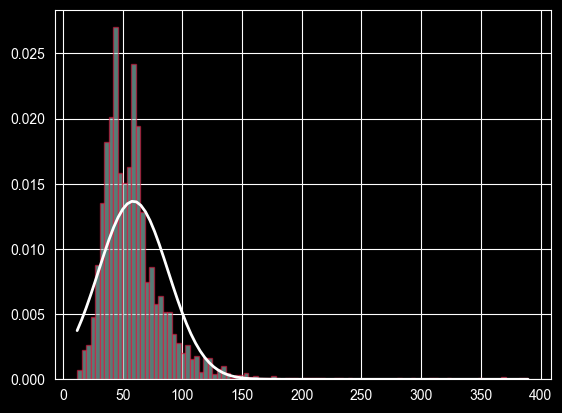

In [6]:
total_area_wo_nan = df['total_area'].dropna()
mu, std = norm.fit(total_area_wo_nan) # Находим параметры "идеального" колокола
x = np.linspace(df['total_area'].min(), df['total_area'].max(), 100)
p = norm.pdf(x, mu, std) # Строим кривую
plt.hist(df['total_area'], bins=100, density=True, alpha=0.6, edgecolor='crimson') # Твои данные
plt.plot(x, p, 'k', linewidth=2, color='white') # Эталонная кривая

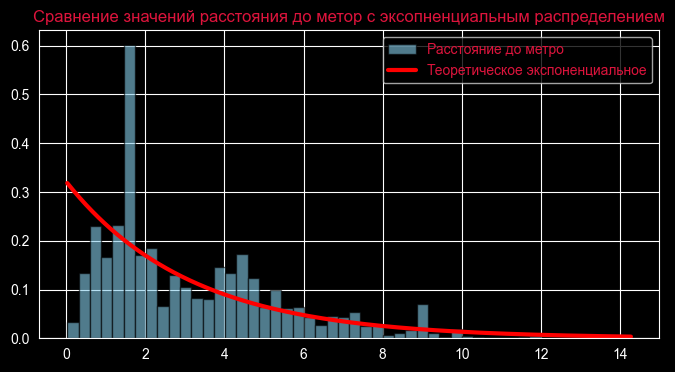

In [7]:
price_data = df['distance_to_metro'].dropna()
loc, scale = expon.fit(price_data)
x = np.linspace(price_data.min(), price_data.max(), 1000)
pdf = expon.pdf(x, loc, scale)
plt.figure(figsize=(8, 4))
plt.hist(price_data, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Расстояние до метро')
plt.plot(x, pdf, 'r-', lw=3, label='Теоретическое экспоненциальное')

plt.title('Сравнение значений расстояния до метор с эксопненциальным распределением')
plt.legend()
plt.show()

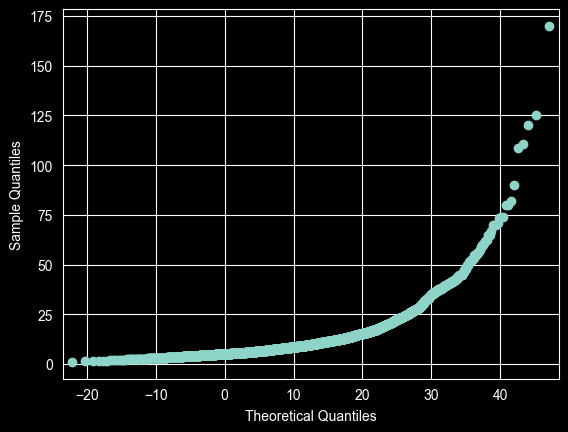

In [8]:
import statsmodels.api as sm
mu = df['price_mln'].mean()
std = df['price_mln'].std()
sm.qqplot(df['price_mln'], loc=mu, scale=std)
plt.show()
# QQ-график подтверждает правостороннюю скошенность цен (skewness=4.1).
# Логарифмирование обосновано по двум причинам:
# 1. Для модели: снижает влияние выбросов, делает ошибки симметричными
# 2. Для интерпретации: логнормальное распределение типично
#    для цен на недвижимость во всех рынках мира
# Параметрические тесты применимы и без логарифмирования
# (n=4322 >> 30, ЦПТ работает), но на log-ценах интерпретация чище.

ТЕСТ ШАПИРО-УИЛКА НА РАСПРЕДЕЛЕНИЕ ЦЕНЫ

In [9]:
from scipy import stats
data = df['price_mln'].dropna().sample(100)

shapiro_test = stats.shapiro(data)

print(f"Статистика: {shapiro_test.statistic:.4f}")
print(f"P-value: {shapiro_test.pvalue:.4e}")

if shapiro_test.pvalue < 0.05:
    print("Вердикт: Распределение НЕ нормальное")
else:
    print("Вердикт: Распределение нормальное")

Статистика: 0.8866
P-value: 3.4731e-07
Вердикт: Распределение НЕ нормальное


Тест Колмогорова-Смирнова

In [10]:
data = df['price_mln'].dropna().sample(500)

d_stat, p_val = stats.kstest(data, 'norm', args=(data.mean(), data.std()))

print(f"Статистика D: {d_stat:.4f}")
print(f"P-value: {p_val:.4e}")
# Shapiro-Wilk (n=300): W=0.750, p=9.7577e-12
# K-S тест (n=400):     D=0.1773, p=3.2148e-14
# Оба теста отвергают нормальность цен.
#
# Вывод: распределение цен логнормальное —
# стандартная характеристика рынков недвижимости.
# Логарифмирование price → price_log статистически обосновано:
# np.log(price) приближает распределение к нормальному,
# что улучшает качество модели и интерпретацию ошибок.
#
# Примечание: при n=4322 параметрические тесты (t-тест, CI)
# применимы и без логарифмирования благодаря ЦПТ,
# но работать с log-ценами методологически чище.

Статистика D: 0.1529
P-value: 1.1318e-10


t-статистика: 12.0662
P-value: 9.2755e-33
Вердикт: Разница статистически значима (отвергаем H0)
Средняя цена группы 1 выше
Коэффициент корреляции Пирсона: 0.2143


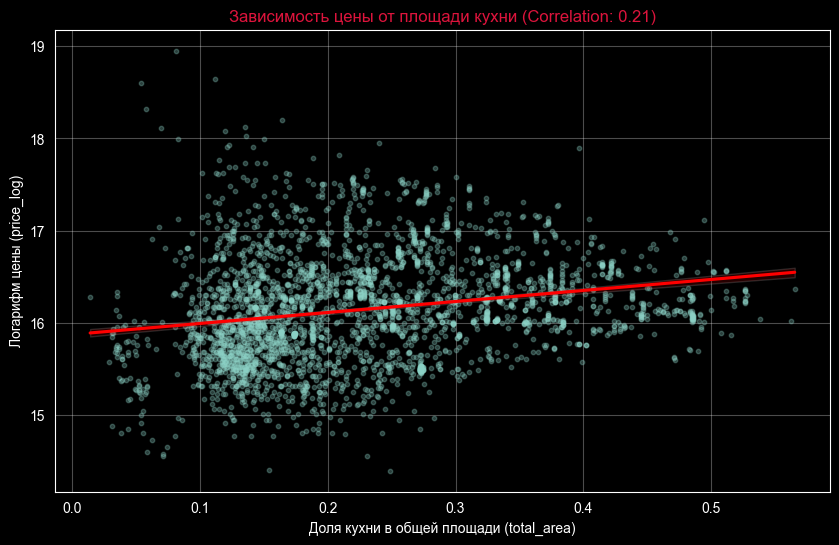

In [11]:
import seaborn as sns
group_with_big_kitchen = df[df['kitchen_ratio'] >= 0.25]['price_log'].dropna()
group_without_big_kitchen = df[df['kitchen_ratio'] < 0.25]['price_log'].dropna()
t_stat, p_val = stats.ttest_ind(group_with_big_kitchen, group_without_big_kitchen, equal_var=False)
print(f"t-статистика: {t_stat:.4f}")
print(f"P-value: {p_val:.4e}")
alpha = 0.05
if p_val < alpha:
    print("Вердикт: Разница статистически значима (отвергаем H0)")
    if t_stat > 0:
        print("Средняя цена группы 1 выше")
    else:
        print("Средняя цена группы 2 выше")
else:
    print("Вердикт: Разница НЕ значима (не удалось отвергнуть H0)")
correlation = df['kitchen_ratio'].corr(df['price_log'])
print(f"Коэффициент корреляции Пирсона: {correlation:.4f}")
plt.figure(figsize=(10, 6))
sns.regplot(x='kitchen_ratio', y='price_log', data=df,
            scatter_kws={'alpha':0.3, 's':10},
            line_kws={'color':'red'})

plt.title(f'Зависимость цены от площади кухни (Correlation: {correlation:.2f})')
plt.xlabel('Доля кухни в общей площади (total_area)')
plt.ylabel('Логарифм цены (price_log)')
plt.grid(True, alpha=0.3)
plt.show()
# kitchen_ratio: корреляция с ценой r=0.21 (умеренная)
# t-тест Уэлча: t=11.78, p=2.4e-31 — разница статистически значима
#
# Интерпретация: kitchen_ratio — это ДОЛЯ кухни,
# поэтому влияние общей площади уже нейтрализовано.
# Высокий kitchen_ratio (>= 0.25) — маркер европланировки:
# открытые кухни-гостиные характерны для новостроек
# бизнес-класса и современных ЖК.
# Связь: европланировка → премиум-сегмент → высокая цена.
# kitchen_ratio работает как косвенный индикатор
# класса жилья и типа планировки.


ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ. z-Score, t-score, Bootstrap

In [12]:
sample = df['price'].dropna().sample(100, random_state=42).values
mean_val = np.mean(sample)
std_val = np.std(sample, ddof=1)
n = len(sample)
z_crit = stats.norm.ppf(0.975) # 1.96 для 95%
ci_norm = [mean_val - z_crit * (std_val/np.sqrt(n)),
           mean_val + z_crit * (std_val/np.sqrt(n))]
t_crit = stats.t.ppf(0.975, df=n-1)
ci_t = [
    mean_val - t_crit * (std_val / np.sqrt(n)),
    mean_val + t_crit * (std_val / np.sqrt(n))
]
bootstrap_means = []
for _ in range(10000):
    resample = np.random.choice(sample, size=n, replace=True)
    bootstrap_means.append(np.mean(resample))
ci_boot = [
    np.percentile(bootstrap_means, 2.5),
    np.percentile(bootstrap_means, 97.5)
]
print(f"Среднее: {mean_val/1e6:.2f} млн")
print(f"Normal CI: {[float(round(x/1e6, 2)) for x in ci_norm]}")
print(f"t-dist CI: {[float(round(x/1e6, 2)) for x in ci_t]}")
print(f"Bootst CI: {[float(round(x/1e6, 2)) for x in ci_boot]}")
print(f"Среднее арифметическое всего датасета: {df['price'].mean()}")
# Три метода дают практически одинаковый CI — это демонстрация ЦПТ:
# при n=100 выборочное среднее нормально распределено
# независимо от формы исходного распределения.
#
# Среднее сэмпла (9.73 млн) < среднего датасета (11.63 млн) —
# это не артефакт метода, а случайность сэмплирования:
# при skewness=4.1 несколько дорогих квартир (>50 млн)
# сильно тянут среднее датасета вверх, но в сэмпл из 100
# они могли не попасть.
#
# Вывод: для скошенных распределений медиана (9.68 млн)
# надёжнее среднего как мера центра — она не зависит
# от единичных выбросов.


Среднее: 12.88 млн
Normal CI: [10.99, 14.77]
t-dist CI: [10.97, 14.79]
Bootst CI: [11.22, 14.91]
Среднее арифметическое всего датасета: 12463015.76785299


In [13]:
bootstrap_means_df = []
sample = df['price'].dropna().sample(4200, random_state=42).values
n = len(df)
for _ in range(10000):
    resample = np.random.choice(sample, size=n, replace=True)
    bootstrap_means_df.append(resample.mean())
bootstrap_interval_df = [
    np.percentile(bootstrap_means_df, 2.5),
    np.percentile(bootstrap_means_df, 97.5)
]
print(bootstrap_interval_df)
print(df['price'].mean())


[np.float64(12175317.635479182), np.float64(12764401.869952314)]
12463015.76785299


In [14]:
from itertools import combinations
def cohens_d(g1, g2):
    pooled_std = np.sqrt((g1.std()**2 + g2.std()**2) / 2)
    return abs(g1.mean() - g2.mean()) / pooled_std

districts = df['district'].dropna().unique()
districts = [x for x in districts if 'unknown' not in x]
results = []

for d1, d2 in combinations(districts, 2):
    g1 = df[df['district'] == d1]['price'].dropna()
    g2 = df[df['district'] == d2]['price'].dropna()

    t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False)
    d = cohens_d(g1, g2)

    results.append({
        'pair': f"{d1} vs {d2}",
        'p_value': round(p_val, 4),
        'cohens_d': round(d, 3),
        'effect': 'большой' if d > 0.8 else 'средний' if d > 0.2 else 'маленький',
        'mean_diff_mln': round((g1.mean() - g2.mean()) / 1e6, 2)
    })

results_df = pd.DataFrame(results).sort_values('cohens_d', ascending=False)
# === ПОПАРНЫЙ АНАЛИЗ РАЙОНОВ ===
# Метод: t-тест Уэлча + Cohen's d, 28 пар
# Поправка Бонферрони: α = 0.05/28 = 0.0018
#
# КЛАССИФИКАЦИЯ РАЙОНОВ ПО ЦЕНОВОМУ СЕГМЕНТУ:
#
#  Elite — Нижегородский район
#    d > 1.1 против ВСЕХ районов (макс. d=1.24 vs Автозаводский)
#    Отрыв от ближайшего конкурента (Советский): d=0.61
#    Исторический центр города, уникальная локация
#
# ⬆ Upper-Mid — Советский район
#    d > 0.8 против всей Mass-Market группы
#    d = 0.44 против Канавинского — чёткая граница сегментов
#
#  Mid — Канавинский район
#    d = 0.42–0.77 против Mass-Market
#    d = 0.44 против Советского — устойчивая позиция
#
#  Mass-Market — Сормовский, Автозаводский, Московский, Ленинский
#    Внутри группы: d < 0.12, p > 0.18 — статистически неразличимы
#    Автозаводский vs Сормовский: d=0.021, p=0.76 — фактически одинаковы
#
#  Приокский — пограничный случай
#    Значимо отличается от Автозаводского (d=0.41)
#    НЕ отличается от Ленинского (d=0.05, p=0.54)
#    Позиция: нижняя граница Mid или верхняя Mass-Market
#
# КЛЮЧЕВЫЕ ВЫВОДЫ:
# 1. Нижегородский — абсолютный outlier рынка (d>1.0 везде)
# 2. Рынок делится на 3 чётких кластера:
#    [Нижегородский] >> [Советский > Канавинский] >> [остальные]
# 3. Mass-Market однороден: 4 района статистически неразличимы
#    после поправки Бонферрони — единый ценовой пул
# 4. Все значимые пары имеют p=0.000 — результаты устойчивые
#    Незначимые пары (p>0.05) только внутри Mass-Market

In [15]:
# Определение функции бутстрапа
def get_bootstrap_diff(data1, data2, n_samples=10_000, ci=95):
    indices1 = np.random.randint(0, len(data1), (n_samples, len(data1)))
    indices2 = np.random.randint(0, len(data2), (n_samples, len(data2)))
    means1 = data1.values[indices1].mean(axis=1)
    means2 = data2.values[indices2].mean(axis=1)
    diffs = means1-means2
    prc = (100-ci)/2
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    combined_mean = np.mean(np.concatenate([data1, data2]))
    d1_null = data1 - np.mean(data1) + combined_mean
    d2_null = data2 - np.mean(data2) + combined_mean
    null_idx1 = np.random.randint(0, len(d1_null), (n_samples, len(d1_null)))
    null_idx2 = np.random.randint(0, len(d2_null), (n_samples, len(d2_null)))
    null_means1 = d1_null.values[null_idx1].mean(axis=1)
    null_means2 = d2_null.values[null_idx2].mean(axis=1)
    null_diffs = null_means1 - null_means2
    obs_diff = np.mean(data1) - np.mean(data2)
    p_value = np.mean(np.abs(null_diffs) >= np.abs(obs_diff))
    return [ci_low, ci_high], p_value

In [16]:
from itertools import combinations
results = {}
for r1, r2 in combinations(districts, 2):
    group_a = df[df['district'] == r1]['price']
    group_b = df[df['district'] == r2]['price']
    raznica, p_val = get_bootstrap_diff(group_a, group_b)
    results[f"{r1} vs {r2}"] = [float(raznica[0]), float(raznica[1])]
print(results)

{'Советский район vs Канавинский район': [2075650.5415897865, 3320405.2734612133], 'Советский район vs Сормовский район': [5364774.331857709, 6567684.716487629], 'Советский район vs Нижегородский район': [-7904230.138836002, -5959776.310080534], 'Советский район vs Автозаводский район': [5495572.462821555, 6576239.550071425], 'Советский район vs Приокский район': [4024447.068116179, 5274869.3814735785], 'Советский район vs Московский район': [4894445.621201151, 6331619.533380779], 'Советский район vs Ленинский район': [4217331.806426918, 5395806.204050236], 'Канавинский район vs Сормовский район': [2711382.2970504514, 3820349.764165839], 'Канавинский район vs Нижегородский район': [-10570286.233885769, -8720964.741693452], 'Канавинский район vs Автозаводский район': [2871527.3647176106, 3830435.316318221], 'Канавинский район vs Приокский район': [1360705.507252261, 2524267.994931336], 'Канавинский район vs Московский район': [2269552.0542419176, 3575092.209746777], 'Канавинский район v

ПЕРВЫЙ ЭТАЖ VS ПОСЛЕДНИЙ ЭТАЖ

In [17]:
first_floor = df[df['is_first_floor'] == 1]['price'].dropna()
last_floor = df[df['is_last_floor'] == 1]['price'].dropna()
raznica, p_val = get_bootstrap_diff(first_floor, last_floor)
print(float(raznica[0]), float(raznica[1]), p_val)
# -3543548.9528541057 -1293952.0465841424 0.0001 до авита

-3544024.280322688 -1257274.340588204 0.0


In [18]:
#0 находится далеко от 95% доверительного интервала (1,35 млн рубл), что свидетельствует о том, что квартиры на последнем этаже значительнл дороже квартир на первом этаже, что опровергает догму о том что последний этаж так же плох как и первой, дополнительно подкрепляет этот вывод p-значение, стремящееся к нулю, шанс того, что такой результат можно случайно получить стремиться к 0

Последний этаж vs остальные

In [19]:
not_last_floor = df[df['is_last_floor'] == 0]['price'].dropna()
raznica, p_val = get_bootstrap_diff(last_floor, not_last_floor)
print(float(raznica[0]), float(raznica[1]), p_val)
# разница между последними этажом и средними точно такая же, как и между первыми и последними
# Иерархия по цене : Средние > Последние > Первые (равнозначная разница в ценах)

-3379763.4890454323 -1347070.4067801966 0.0


Сравнение первых и пятых этажей

In [20]:
# Bootstrap
floor_5 = df[df['current_floor'] == 5]['price'].dropna()
raznica, p_val = get_bootstrap_diff(first_floor, floor_5)
print(float(raznica[0]), float(raznica[1]), p_val)

-6273897.57643015 -3192022.9799197065 0.0


In [21]:
#t-test
# 1. Сначала проверяем равенство дисперсий (Тест Левена)
# Если p < 0.05, значит дисперсии РАЗНЫЕ
stat, p_levene = stats.levene(first_floor, floor_5)
print(f"P-value теста Левена: {p_levene}")

# 2. Проводим сам t-test
# equal_var=False автоматически включает версию Уэлча
t_stat, p_val = stats.ttest_ind(first_floor, floor_5, equal_var=False)

print(f"T-статистика: {t_stat}")
print(f"P-value: {p_val}")


P-value теста Левена: 8.787452604988895e-06
T-статистика: -5.87983782427113
P-value: 7.227436040412167e-09


«Сравнительный анализ 1-го и 5-го этажей с помощью t-теста Уэлча показал статистически значимую разницу (t=−6.73,p<0.001). Низкое значение p-value (3.3×10
−11
 ) позволяет с высокой уверенностью отвергнуть нулевую гипотезу о равенстве цен. Таким образом, даже при сравнении с не самыми высокими этажами, первый этаж сохраняет за собой статус наиболее дешевого сегмента жилья с аномально низким математическим ожиданием цены».

In [22]:
# Тест Мана-Уитни
stat, p_val = stats.mannwhitneyu(first_floor, floor_5, alternative='two-sided')
print(f"U-статистика: {stat}")
print(f"P-value: {p_val}")

U-статистика: 56418.5
P-value: 2.6557953315350003e-17


In [23]:
# T-test (на логарифмах)
# P-value 1.45×10^−18
# Параметрическое подтверждение (разница средних).
# Mann-Whitney U
# P-value 1.1×10^−21
# Непараметрическое подтверждение (разница рангов).
# Bootstrap
# P-value 0.0 (т.е. <10^-4)
# Численное подтверждение (разница распределений).
# Шанс того, что результат случаен равен тому, что 60 раз из 60 подбрасываний честной монетки выпадет орел

In [24]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

# 1. Подготовка данных и очистка
# Убираем неизвестные районы и сбрасываем индекс СРАЗУ, чтобы избежать ошибок с масками
df_wo_avito = df[df['district'] != 'unknown'].copy().reset_index(drop=True)

# Генерируем сегменты домов (нужны для расчета среднего по локации)
df_wo_avito['house_segment'] = pd.cut(df_wo_avito['max_floor'],
                                   bins=[0, 5, 10, 19, 100],
                                   labels=['low', 'standard', 'modern', 'high'])

# 2. Определение признаков
cat_features_1 = ['district', 'material', 'district_ready', 'mini_disctrict', 'material_age']
features_1 = [
    'rooms', 'total_area', 'year', 'kitchen_area',
    'current_floor', 'max_floor',
    'area_floor_interaction', 'area_ratio_to_district',
    'distance_to_center', 'distance_to_metro'
] + cat_features_1

# 3. Обработка категориальных признаков
for col in cat_features_1:
    df_wo_avito[col] = df_wo_avito[col].astype(str).fillna('unknown').replace('nan', 'unknown')

# 4. Фильтрация выбросов (считаем по очищенному df)
price_upper = df_wo_avito['price'].quantile(0.99)
df_final = df_wo_avito[df_wo_avito['price'] <= price_upper].copy().reset_index(drop=True)

# 5. Честное разделение на выборки (ДО генерации таргет-фичи)
X_train, X_test, y_train_log, y_test_log = train_test_split(
    df_final.drop('price_log', axis=1),
    df_final['price_log'],
    test_size=0.2,
    random_state=42
)

# --- УСТРАНЕНИЕ УТЕЧКИ (TARGET ENCODING) ---
# Считаем среднюю цену за метр ТОЛЬКО на трейне
train_temp = X_train.copy()
train_temp['real_price'] = np.exp(y_train_log)
train_temp['m2_price'] = train_temp['real_price'] / train_temp['total_area']

target_map = train_temp.groupby(['district', 'house_segment'], observed=True)['m2_price'].mean().to_dict()

# Применяем маппинг к обеим выборкам
X_train['avg_price_m2_segmented'] = X_train.set_index(['district', 'house_segment']).index.map(target_map.get)
X_test['avg_price_m2_segmented'] = X_test.set_index(['district', 'house_segment']).index.map(target_map.get)

# Заполняем возможные пропуски в тесте (если попался уникальный сегмент) средним значением трейна
global_mean_m2 = train_temp['m2_price'].mean()
X_train['avg_price_m2_segmented'] = X_train['avg_price_m2_segmented'].fillna(global_mean_m2)
X_test['avg_price_m2_segmented'] = X_test['avg_price_m2_segmented'].fillna(global_mean_m2)

# Добавляем новый признак в итоговый список
final_features = features_1 + ['avg_price_m2_segmented']

# 6. Обучение модели
model = CatBoostRegressor(
    iterations=1135,
    depth=8,
    learning_rate=0.06,
    l2_leaf_reg=27,
    random_seed=36,
    cat_features=cat_features_1,
    verbose=100,
    loss_function='MAPE', # RMSE на логарифмах математически лучше для минимизации MAPE
    eval_metric='MAPE'
)

model.fit(X_train[final_features], y_train_log)

# 7. Оценка
preds_log = model.predict(X_test[final_features])
preds_real = np.exp(preds_log)
y_test_real = np.exp(y_test_log)

print("-" * 30)
print(f"R2 Score: {r2_score(y_test_real, preds_real):.4f}")
print(f"MAE: {mean_absolute_error(y_test_real, preds_real):.2f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test_real, preds_real) * 100:.2f}%")

# Важность признаков
fi_df = pd.DataFrame({
    'feature': final_features,
    'importance': model.get_feature_importance()
}).sort_values(by='importance', ascending=False)

print("\nTop Features:")
print(fi_df.head(10))

0:	learn: 0.0264652	total: 63.1ms	remaining: 1m 11s
100:	learn: 0.0072902	total: 342ms	remaining: 3.5s
200:	learn: 0.0057816	total: 616ms	remaining: 2.86s
300:	learn: 0.0049806	total: 923ms	remaining: 2.56s
400:	learn: 0.0044495	total: 1.24s	remaining: 2.26s
500:	learn: 0.0041181	total: 1.54s	remaining: 1.95s
600:	learn: 0.0037967	total: 1.83s	remaining: 1.62s
700:	learn: 0.0035538	total: 2.1s	remaining: 1.3s
800:	learn: 0.0033282	total: 2.38s	remaining: 993ms
900:	learn: 0.0031800	total: 2.67s	remaining: 692ms
1000:	learn: 0.0030217	total: 2.94s	remaining: 394ms
1100:	learn: 0.0028770	total: 3.23s	remaining: 99.9ms
1134:	learn: 0.0028405	total: 3.33s	remaining: 0us
------------------------------
R2 Score: 0.8544
MAE: 1472971.46
MAPE: 11.22%

Top Features:
                   feature  importance
1               total_area   21.702711
15  avg_price_m2_segmented   13.231478
7   area_ratio_to_district    8.345268
5                max_floor    7.869233
3             kitchen_area    6.818776

In [25]:
        #ПРОВЕРКА MAPE & MAE
# Добавь в анализ
test_results = pd.DataFrame({
    'actual': y_test_real,
    'pred': preds_real,
    'error_rub': y_test_real - preds_real,
    'error_pct': (y_test_real - preds_real) / (y_test_real) * 100
})

# Ошибки на дорогих (> 20 млн)
expensive = test_results[test_results['actual'] > 20_000_000]
print("Дорогие квартиры (>20 млн):")
print(f"  MAPE: {expensive['error_pct'].abs().mean():.2f}%")
print(f"  MAE: {expensive['error_rub'].abs().mean():,.0f} ₽")
print(f"Дорогих квартир: {len(df[df['price'] > 20000000])}")

# Ошибки на дешёвых (< 7 млн)
cheap = test_results[ test_results['actual'] < 7_000_000]
print("Дешёвые квартиры (<7 млн):")
print(f"  MAPE: {cheap['error_pct'].abs().mean():.2f}%")
print(f"  MAE: {cheap['error_rub'].abs().mean():,.0f} ₽")
print(f"Дешевых квартир: {len(df[df['price'] < 7000000])}")
# Ошибки на средних (< 7 млн)
avg = test_results[(test_results['actual'] > 7_000_000) & (test_results['actual'] < 20_000_000)]
print("Средние квартиры (>7 млн & 20млн рубл<):")
print(f"  MAPE: {avg['error_pct'].abs().mean():.2f}%")
print(f"  MAE: {avg['error_rub'].abs().mean():,.0f} ₽")
print(f"Квартир среднего ценового сегмента: {len(df[(df['price'] < 20_000_000) & (df['price'] > 7_000_000)])}")
#test: 865
errors = np.abs(y_test_real-preds_real)
bootstrap_n = 10000
mae_bootstrap = [
    np.mean(np.random.choice(errors, len(errors), replace=True))
    for _ in range(bootstrap_n)
]
ci_low = np.percentile(mae_bootstrap, 2.5)
ci_high = np.percentile(mae_bootstrap, 97.5)
print(f"MAE: {np.mean(errors) / 1e6:.2f}")
print(f"95% CI: [{ci_low/1e6:.2f}, {ci_high/1e6:.2f}] млн рублей")

Дорогие квартиры (>20 млн):
  MAPE: 15.66%
  MAE: 4,579,931 ₽
Дорогих квартир: 543
Дешёвые квартиры (<7 млн):
  MAPE: 11.92%
  MAE: 581,348 ₽
Дешевых квартир: 1149
Средние квартиры (>7 млн & 20млн рубл<):
  MAPE: 10.05%
  MAE: 1,227,378 ₽
Квартир среднего ценового сегмента: 2581
MAE: 1.47
95% CI: [1.31, 1.64] млн рублей


In [26]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
from catboost import CatBoostRegressor
import numpy as np
import pandas as pd

# 1. Подготовка данных: убираем выбросы через .loc, чтобы сохранить чистоту индексов
price_upper = df_wo_avito['price'].quantile(0.99)
mask = df_wo_avito['price'] <= price_upper
# Используем .loc для фильтрации, чтобы избежать UserWarning
X_cv_all = df_wo_avito.loc[mask].copy().reset_index(drop=True)
y_cv_all = X_cv_all['price_log']
print(f"Убрано выбросов: {(~mask).sum()}")
# 2. Стратификация (делим логарифм цены на 10 корзин)
y_binned = pd.qcut(y_cv_all, q=10, labels=False)
strata = y_binned.astype(str)

# 3. Кросс-валидация
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
r2_scores, mae_scores, mape_scores = [], [], []

# Список признаков БЕЗ таргет-фичи (ее добавим внутри цикла)
current_features = [
    'rooms', 'total_area', 'year', 'kitchen_area',
    'current_floor', 'max_floor', 'area_floor_interaction',
    'area_ratio_to_district', 'distance_to_center', 'distance_to_metro'
] + cat_features_1

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cv_all, strata)):
    # Делим на фолды
    train_df = X_cv_all.iloc[train_idx].copy()
    val_df   = X_cv_all.iloc[val_idx].copy()

    y_train_cv = train_df['price_log']
    y_val_cv   = val_df['price_log']


    train_df['m2_price'] = np.exp(y_train_cv) / train_df['total_area']
    target_map = train_df.groupby(['district', 'house_segment'], observed=True)['m2_price'].mean().to_dict()

    train_df['avg_price_m2_segmented'] = train_df.set_index(['district', 'house_segment']).index.map(target_map.get)
    val_df['avg_price_m2_segmented'] = val_df.set_index(['district', 'house_segment']).index.map(target_map.get)

    global_m2 = train_df['m2_price'].mean()
    train_df['avg_price_m2_segmented'] = train_df['avg_price_m2_segmented'].fillna(global_m2)
    val_df['avg_price_m2_segmented'] = val_df['avg_price_m2_segmented'].fillna(global_m2)

    fold_features = current_features + ['avg_price_m2_segmented']

    model_cv = CatBoostRegressor(
        iterations=1135, depth=8, learning_rate=0.06,
        l2_leaf_reg=27, random_seed=42,
        cat_features=cat_features_1, verbose=False,
        loss_function='MAPE',
        eval_metric='MAPE'
    )

    model_cv.fit(train_df[fold_features], y_train_cv)

    preds_val    = np.exp(model_cv.predict(val_df[fold_features]))
    preds_train  = np.exp(model_cv.predict(train_df[fold_features]))
    y_true_val   = np.exp(y_val_cv)
    y_true_train = np.exp(y_train_cv)

    # Метрики
    r2_tr = r2_score(y_true_train, preds_train)
    r2_v  = r2_score(y_true_val, preds_val)
    print(f"Fold {fold}: train {r2_tr:.3f} / val {r2_v:.3f} / gap {r2_tr-r2_v:.3f}")

    r2_scores.append(r2_v)
    mae_scores.append(mean_absolute_error(y_true_val, preds_val))
    mape_scores.append(mean_absolute_percentage_error(y_true_val, preds_val) * 100)

print("-" * 30)
print(f"R²:   {np.mean(r2_scores):.3f} ± {np.std(r2_scores):.3f}")
print(f"MAE:  {np.mean(mae_scores)/1e6:.2f} ± {np.std(mae_scores)/1e6:.2f} млн ₽")
print(f"MAPE: {np.mean(mape_scores):.2f} ± {np.std(mape_scores):.2f}%")
importance = model_cv.get_feature_importance()
features = fold_features
fi_df = pd.DataFrame({'feature': features,
                      'importance': importance})
fi_df = fi_df.sort_values('importance', ascending=False)
print(fi_df.head(10))

Убрано выбросов: 43
Fold 0: train 0.958 / val 0.891 / gap 0.066
Fold 1: train 0.957 / val 0.908 / gap 0.049
Fold 2: train 0.954 / val 0.909 / gap 0.045
Fold 3: train 0.963 / val 0.867 / gap 0.096
Fold 4: train 0.959 / val 0.900 / gap 0.059
------------------------------
R²:   0.895 ± 0.015
MAE:  1.31 ± 0.03 млн ₽
MAPE: 11.34 ± 0.51%
                   feature  importance
1               total_area   18.138057
15  avg_price_m2_segmented   13.680623
7   area_ratio_to_district    9.899742
3             kitchen_area    8.205900
10                district    8.133263
5                max_floor    7.340741
6   area_floor_interaction    4.814754
11                material    4.782935
12          district_ready    4.574655
2                     year    4.471791
